# Seed sensitivity of the matched-N ticker bootstrap

**Question.** The benchmark's point estimates (per-metric score `s`, aggregate `G`) and their
95% bootstrap CIs are computed once, at `seed=42`. This notebook asks: how much would those
numbers move if the whole run were reseeded? Two things are tested separately:

1. **Point-estimate stability** — the score/`G` are means over `B` draws of `tickers_per_draw`
   tickers sampled with replacement from the 600-ticker pool. Reseeding redraws *which*
   tickers land in each draw. Some movement is expected and correct: it's exactly the
   sampling variability the CI is supposed to quantify.
2. **CI stability** — the CI itself is a bootstrap over only `B` outer draws (a bootstrap of a
   bootstrap). With that few replicates, the *interval bounds* may jitter more across seeds
   than the point estimate does.

**What this checks, concretely:**
- Do other seeds' point estimates fall inside the `seed=42` (canonical) CI?
- How much does CI width itself vary across seeds (a large swing would flag `B` as undersized
  for a stable interval)?
- Does the *qualitative* story — generator rank order by `G`, which stylized facts AIL nears
  parity on — ever flip across seeds? That is the real robustness bar, not decimal-level
  reproducibility.

Every result in this analysis lives in this notebook only — no CSVs or other files are written
as a side effect. Re-running end to end regenerates everything from the curated parquet data.


In [1]:
%matplotlib inline
import time

import matplotlib.pyplot as plt
import pandas as pd

from fineval.benchmark.config import CURATED_DIR, build_metrics
from fineval.bootstrap import MatchedTickerBootstrap
from fineval.data import CuratedParquetLoader, GBMBaselineLoader, MSVBaselineLoader
from fineval.preprocessing import PreprocessingPipeline

pd.set_option("display.width", 120)

SEEDS = [42, 1, 2, 3, 4, 5, 6, 7]  # 42 is the canonical/anchor seed used elsewhere in the repo
N_RESAMPLES = 100
TICKERS_PER_DRAW = 200

SEEDS, N_RESAMPLES, TICKERS_PER_DRAW

([42, 1, 2, 3, 4, 5, 6, 7], 100, 200)

## Load and preprocess once

Data loading and FFF deseasonalization carry no randomness, so this happens once and is
reused for every seed below — only the bootstrap engine's `seed` varies from here on.


In [2]:
print("Loading curated datasets...")
real = CuratedParquetLoader(
    parquet_path=str(CURATED_DIR / "real_prices.parquet"), name="Real", is_synthetic=False
).load()
ail = CuratedParquetLoader(
    parquet_path=str(CURATED_DIR / "ail_prices.parquet"), name="AIL", is_synthetic=True
).load()
gbm = GBMBaselineLoader(parquet_path=str(CURATED_DIR / "gbm_prices.parquet")).load()
msv = MSVBaselineLoader(parquet_path=str(CURATED_DIR / "msv_prices.parquet")).load()

print("Preprocessing (log returns, overnight mask, conditional FFF)...")
deseas_real = None
synthetics = {}
for dataset in (ail, gbm, msv):
    pipeline = PreprocessingPipeline().run(real.prices, dataset.prices)
    synthetics[dataset.name] = pipeline.deseas_synthetic
    if deseas_real is None:
        deseas_real = pipeline.deseas_real

print(
    "Real panel:", deseas_real.shape, "| Synthetics:", {k: v.shape for k, v in synthetics.items()}
)

Loading curated datasets...


Preprocessing (log returns, overnight mask, conditional FFF)...


Real panel: (53850, 600) | Synthetics: {'AIL': (53850, 600), 'GBM': (53850, 600), 'MSV': (53850, 600)}


## Run the bootstrap once per seed

Same data, same metrics, same `n_resamples`/`tickers_per_draw` — only `seed` changes.


In [3]:
per_metric_rows = []
aggregate_rows = []
timings = []

for seed in SEEDS:
    t0 = time.monotonic()
    engine = MatchedTickerBootstrap(
        metrics=build_metrics(),
        n_resamples=N_RESAMPLES,
        tickers_per_draw=TICKERS_PER_DRAW,
        seed=seed,
    )
    results = engine.run(deseas_real, synthetics)
    aggregate = engine.compute_aggregate()
    dt = time.monotonic() - t0

    results = results.copy()
    results["seed"] = seed
    per_metric_rows.append(results)

    aggregate = aggregate.copy()
    aggregate["seed"] = seed
    aggregate_rows.append(aggregate)

    timings.append({"seed": seed, "duration_seconds": dt})
    print(f"seed={seed}: done in {dt / 60:.1f} min")

per_metric = pd.concat(per_metric_rows, ignore_index=True)
aggregate_all = pd.concat(aggregate_rows, ignore_index=True)
timings = pd.DataFrame(timings)
print("\nAll seeds complete.")

Bootstrap resamples:   0%|          | 0/100 [00:00<?, ?it/s]

Bootstrap resamples:   1%|          | 1/100 [00:23<38:13, 23.17s/it]

Bootstrap resamples:   2%|▏         | 2/100 [00:50<41:54, 25.66s/it]

Bootstrap resamples:   3%|▎         | 3/100 [01:17<42:45, 26.45s/it]

Bootstrap resamples:   4%|▍         | 4/100 [01:42<41:21, 25.85s/it]

...

Bootstrap resamples:  98%|█████████▊| 98/100 [48:57<01:02, 31.39s/it]

Bootstrap resamples:  99%|█████████▉| 99/100 [49:28<00:31, 31.29s/it]

Bootstrap resamples: 100%|██████████| 100/100 [50:00<00:00, 31.63s/it]

Bootstrap resamples: 100%|██████████| 100/100 [50:00<00:00, 30.01s/it]

seed=7: done in 50.0 min

All seeds complete.


## Per-metric scores across seeds

In [4]:
per_metric_pivot = per_metric.pivot_table(
    index=["metric", "generator"], columns="seed", values="score"
)
per_metric_pivot

seed                    1         2         3         4         5         6         7         42
metric generator                                                                                
M1     AIL        0.483121  0.484467  0.499509  0.497565  0.488616  0.499700  0.474321  0.477813
       GBM        0.026065  0.027961  0.026911  0.025948  0.027476  0.029592  0.027536  0.025227
       MSV        0.026057  0.027953  0.026903  0.025940  0.027468  0.029583  0.027528  0.025220
M2     AIL        0.242147  0.253980  0.231222  0.231771  0.250928  0.226791  0.205789  0.203027
       GBM        0.022570  0.023262  0.021498  0.021008  0.021448  0.021135  0.018489  0.018617
       MSV        0.291752  0.312991  0.290244  0.288718  0.280902  0.298930  0.262428  0.265028
M4     AIL        0.381799  0.387701  0.393203  0.368739  0.362956  0.412067  0.383733  0.377893
       GBM        0.130842  0.122948  0.132352  0.117208  0.115646  0.137811  0.128171  0.121177
       MSV        0.188919  0.177799  0.188109  0.165934  0.169682  0.193149  0.184300  0.169739
M6     AIL        0.465314  0.453182  0.472772  0.450480  0.438525  0.455236  0.460185  0.485267
       GBM        0.045903  0.045996  0.044375  0.043734  0.042515  0.047181  0.048062  0.047119
       MSV        0.127988  0.128348  0.125683  0.124914  0.120120  0.132309  0.137323  0.133415

### Point-estimate stability: do other seeds fall inside the seed=42 CI?

In [5]:
anchor = per_metric[per_metric["seed"] == 42].set_index(["metric", "generator"])[
    ["ci_low", "ci_high"]
]

rows = []
for (metric, generator), group in per_metric.groupby(["metric", "generator"]):
    lo, hi = anchor.loc[(metric, generator)]
    others = group.loc[group["seed"] != 42, "score"]
    rows.append(
        {
            "metric": metric,
            "generator": generator,
            "anchor_ci_low": lo,
            "anchor_ci_high": hi,
            "fraction_within_anchor_ci": float(((others >= lo) & (others <= hi)).mean()),
            "score_min": group["score"].min(),
            "score_max": group["score"].max(),
            "score_range": group["score"].max() - group["score"].min(),
        }
    )
containment = pd.DataFrame(rows)
containment

,metric,generator,anchor_ci_low,anchor_ci_high,fraction_within_anchor_ci,score_min,score_max,score_range
0,M1,AIL,0.447064,0.509281,1.000000,0.474321,0.499700,0.025379
1,M1,GBM,0.022653,0.028010,0.857143,0.025227,0.029592,0.004365
2,M1,MSV,0.022636,0.027957,0.857143,0.025220,0.029583,0.004364
3,M2,AIL,0.180850,0.225842,0.142857,0.203027,0.253980,0.050953
4,M2,GBM,0.016349,0.020947,0.142857,0.018489,0.023262,0.004774
5,M2,MSV,0.237034,0.290827,0.571429,0.262428,0.312991,0.050563
6,M4,AIL,0.345897,0.409798,0.857143,0.362956,0.412067,0.049111
7,M4,GBM,0.107632,0.135999,0.857143,0.115646,0.137811,0.022165
8,M4,MSV,0.151527,0.188867,0.714286,0.165934,0.193149,0.027215
9,M6,AIL,0.456287,0.514106,0.428571,0.438525,0.485267,0.046742


### CI-width stability across seeds

In [6]:
per_metric["ci_width"] = per_metric["ci_high"] - per_metric["ci_low"]
ci_width_stats = (
    per_metric.groupby(["metric", "generator"])["ci_width"]
    .agg(["mean", "std", "min", "max"])
    .assign(relative_std=lambda d: d["std"] / d["mean"])
)
ci_width_stats

mean       std       min       max  relative_std
metric generator                                                      
M1     AIL        0.064860  0.003484  0.061462  0.071710      0.053715
       GBM        0.006261  0.000759  0.005357  0.007612      0.121257
       MSV        0.006318  0.000686  0.005320  0.007588      0.108637
M2     AIL        0.054318  0.005721  0.044992  0.063677      0.105328
       GBM        0.005580  0.000537  0.004598  0.006332      0.096274
       MSV        0.058083  0.004027  0.053701  0.063595      0.069333
M4     AIL        0.062858  0.005390  0.055313  0.071051      0.085745
       GBM        0.030744  0.002506  0.028086  0.034478      0.081513
       MSV        0.042067  0.004093  0.037340  0.049142      0.097305
M6     AIL        0.054675  0.005794  0.044691  0.063951      0.105976
       GBM        0.007634  0.000770  0.006526  0.008471      0.100909
       MSV        0.019914  0.002180  0.016003  0.022981      0.109464

## Aggregate G stability

In [7]:
anchor_g = aggregate_all[aggregate_all["seed"] == 42].set_index("generator")[["ci_low", "ci_high"]]

g_rows = []
for generator, group in aggregate_all.groupby("generator"):
    lo, hi = anchor_g.loc[generator]
    others = group.loc[group["seed"] != 42, "G"]
    g_rows.append(
        {
            "generator": generator,
            "anchor_ci_low": lo,
            "anchor_ci_high": hi,
            "fraction_within_anchor_ci": float(((others >= lo) & (others <= hi)).mean()),
            "G_min": group["G"].min(),
            "G_max": group["G"].max(),
            "G_range": group["G"].max() - group["G"].min(),
        }
    )
g_containment = pd.DataFrame(g_rows)
g_containment

,generator,anchor_ci_low,anchor_ci_high,fraction_within_anchor_ci,G_min,G_max,G_range
0,AIL,1.550509,1.767401,0.857143,1.547388,1.684821,0.137432
1,GBM,22.129337,24.690507,0.428571,20.929713,23.378902,2.449189
2,MSV,7.216810,8.123388,0.428571,6.775546,7.639175,0.863629


In [8]:
aggregate_all["ci_width"] = aggregate_all["ci_high"] - aggregate_all["ci_low"]
g_ci_width_stats = (
    aggregate_all.groupby("generator")["ci_width"]
    .agg(["mean", "std", "min", "max"])
    .assign(relative_std=lambda d: d["std"] / d["mean"])
)
g_ci_width_stats

,mean,std,min,max,relative_std
generator,,,,,
AIL,0.236052,0.021526,0.214949,0.271683,0.091192
GBM,3.094178,0.280110,2.561170,3.541923,0.090528
MSV,1.016627,0.064316,0.906578,1.083059,0.063264


### Qualitative stability: does the generator rank order by G ever flip?

In [9]:
orderings = {}
for seed, row in aggregate_all.pivot(index="seed", columns="generator", values="G").iterrows():
    orderings[seed] = tuple(row.sort_values().index)  # ascending G: best fidelity first

unique_orderings = set(orderings.values())
print(
    f"Distinct generator rank-orderings (best/lowest G to worst) across {len(SEEDS)} seeds: {len(unique_orderings)}"
)
for ordering in unique_orderings:
    print(" ", " < ".join(ordering))
orderings

Distinct generator rank-orderings (best/lowest G to worst) across 8 seeds: 1
  AIL < MSV < GBM


{1: ('AIL', 'MSV', 'GBM'),
 2: ('AIL', 'MSV', 'GBM'),
 3: ('AIL', 'MSV', 'GBM'),
 4: ('AIL', 'MSV', 'GBM'),
 5: ('AIL', 'MSV', 'GBM'),
 6: ('AIL', 'MSV', 'GBM'),
 7: ('AIL', 'MSV', 'GBM'),
 42: ('AIL', 'MSV', 'GBM')}

### Per-metric qualitative checks (claims from reasoning.md), across every seed

In [10]:
checks = []

# GBM should be the worst-scoring generator on every metric, every seed.
for (metric, seed), group in per_metric.groupby(["metric", "seed"]):
    worst = group.loc[group["score"].idxmin(), "generator"]
    checks.append(
        {"check": "GBM is worst generator", "metric": metric, "seed": seed, "holds": worst == "GBM"}
    )

# MSV should beat AIL specifically on M2 (the fact MSV was built to specialize in), every seed.
for seed in SEEDS:
    row = per_metric[(per_metric["metric"] == "M2") & (per_metric["seed"] == seed)]
    msv_score = row.loc[row["generator"] == "MSV", "score"].iloc[0]
    ail_score = row.loc[row["generator"] == "AIL", "score"].iloc[0]
    checks.append(
        {
            "check": "MSV beats AIL on M2",
            "metric": "M2",
            "seed": seed,
            "holds": msv_score > ail_score,
        }
    )

checks_df = pd.DataFrame(checks)
checks_df.groupby("check")["holds"].agg(["mean", "sum", "count"])

,mean,sum,count
check,,,
GBM is worst generator,0.75,24,32
MSV beats AIL on M2,1.00,8,8


## Visual: score / G with CI, across seeds

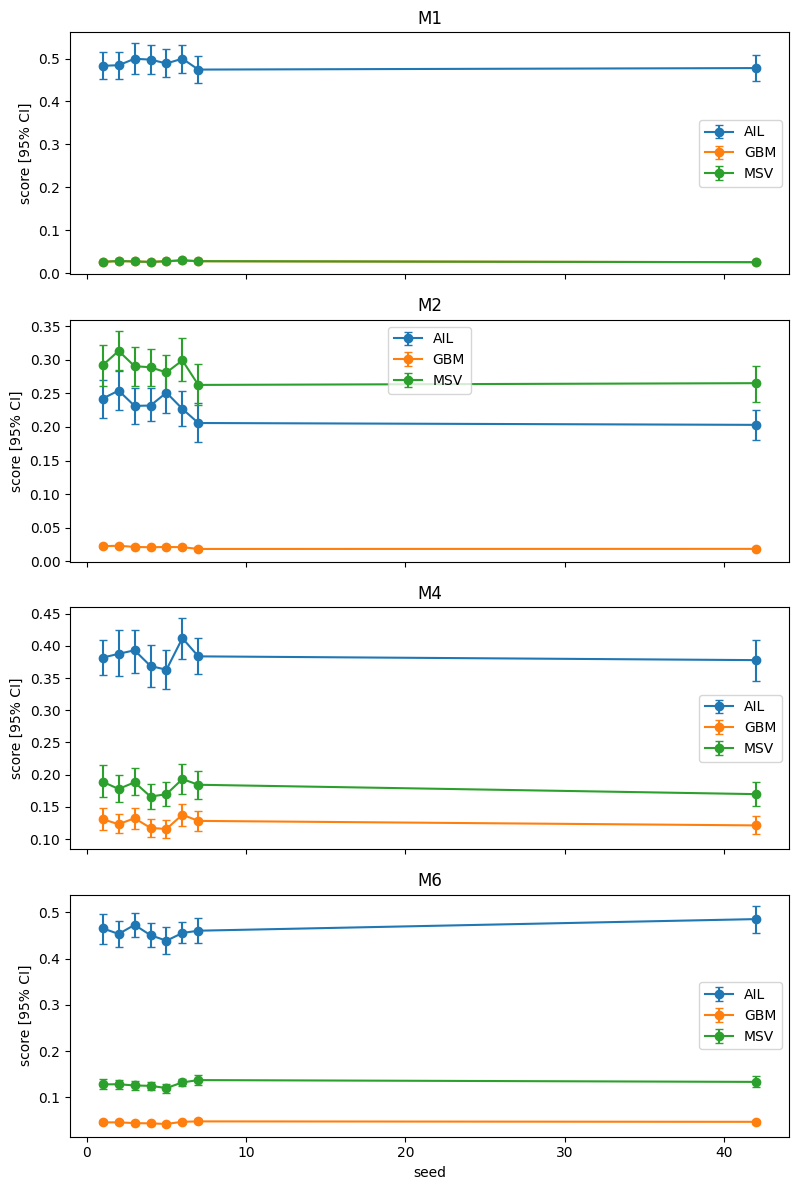

In [11]:
generators = sorted(per_metric["generator"].unique())
metrics = sorted(per_metric["metric"].unique())

fig, axes = plt.subplots(len(metrics), 1, figsize=(8, 3 * len(metrics)), sharex=True)
for ax, metric in zip(axes, metrics, strict=True):
    for generator in generators:
        sub = per_metric[
            (per_metric["metric"] == metric) & (per_metric["generator"] == generator)
        ].sort_values("seed")
        yerr = [sub["score"] - sub["ci_low"], sub["ci_high"] - sub["score"]]
        ax.errorbar(sub["seed"], sub["score"], yerr=yerr, marker="o", capsize=3, label=generator)
    ax.set_title(metric)
    ax.set_ylabel("score [95% CI]")
    ax.legend()
axes[-1].set_xlabel("seed")
fig.tight_layout()
plt.show()

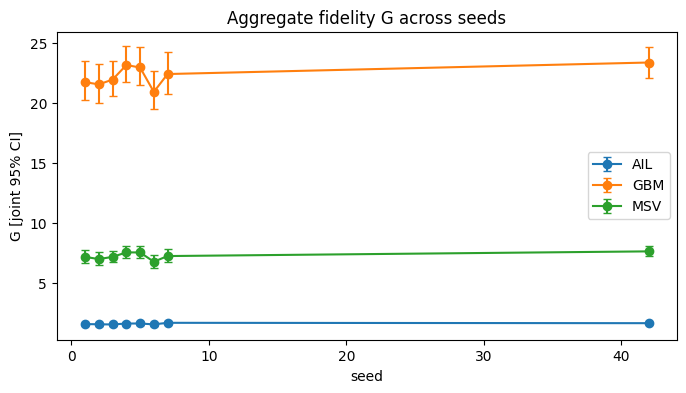

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
for generator in generators:
    sub = aggregate_all[aggregate_all["generator"] == generator].sort_values("seed")
    yerr = [sub["G"] - sub["ci_low"], sub["ci_high"] - sub["G"]]
    ax.errorbar(sub["seed"], sub["G"], yerr=yerr, marker="o", capsize=3, label=generator)
ax.set_xlabel("seed")
ax.set_ylabel("G [joint 95% CI]")
ax.set_title("Aggregate fidelity G across seeds")
ax.legend()
plt.show()

## Timings

In [13]:
print(
    f"Total wall-clock: {timings['duration_seconds'].sum() / 60:.1f} min across {len(SEEDS)} seeds"
)
timings

Total wall-clock: 346.8 min across 8 seeds


,seed,duration_seconds
0,42,2596.938417
1,1,2576.057929
2,2,2531.980770
3,3,2526.114387
4,4,2547.552663
5,5,2522.882727
6,6,2507.748343
7,7,3000.886174


## Summary

In [14]:
print("SEED SENSITIVITY SUMMARY")
print("=" * 60)
print(f"Seeds tested: {SEEDS}")
print(f"Per run: B={N_RESAMPLES}, tickers/draw={TICKERS_PER_DRAW}")
print()
print("Per-metric point estimates: fraction of non-anchor seeds landing inside")
print("the seed=42 CI (1.0 = fully contained):")
print(containment[["metric", "generator", "fraction_within_anchor_ci"]].to_string(index=False))
print()
print("Per-metric CI width relative std across seeds (higher = less stable CI):")
print(ci_width_stats["relative_std"].to_string())
print()
print("Aggregate G: fraction of non-anchor seeds within seed=42 CI:")
print(g_containment[["generator", "fraction_within_anchor_ci"]].to_string(index=False))
print()
print("Aggregate G CI width relative std across seeds:")
print(g_ci_width_stats["relative_std"].to_string())
print()
print(f"Distinct generator rank-orderings by G across {len(SEEDS)} seeds: {len(unique_orderings)}")
for ordering in unique_orderings:
    print("  ", " < ".join(ordering))
print()
print("Qualitative checks (fraction of seeds where the claim holds):")
print(checks_df.groupby("check")["holds"].mean().to_string())

SEED SENSITIVITY SUMMARY
Seeds tested: [42, 1, 2, 3, 4, 5, 6, 7]
Per run: B=100, tickers/draw=200

Per-metric point estimates: fraction of non-anchor seeds landing inside
the seed=42 CI (1.0 = fully contained):
metric generator  fraction_within_anchor_ci
    M1       AIL                   1.000000
    M1       GBM                   0.857143
    M1       MSV                   0.857143
    M2       AIL                   0.142857
    M2       GBM                   0.142857
    M2       MSV                   0.571429
    M4       AIL                   0.857143
    M4       GBM                   0.857143
    M4       MSV                   0.714286
    M6       AIL                   0.428571
    M6       GBM                   0.857143
    M6       MSV                   0.857143

Per-metric CI width relative std across seeds (higher = less stable CI):
metric  generator
M1      AIL          0.053715
        GBM          0.121257
        MSV          0.108637
M2      AIL          0.105328
     